In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Read data

In [ ]:
from pathlib import Path
import pandas as pd

dataset_name = "Labeled_Datasets/Ecuador"  # folder path

dfs = []

drive.mount('/content/drive')
base_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name
print("Running inside Colab. Loading from Google Drive...")


for i in range(1, 31):
    file_name = f"Ecuador_part_{i}.gzip.parquet"
    file_path = base_path / file_name

    print(f"Loading: {file_path}")
    df_part = pd.read_parquet(file_path)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

print("Done! Combined dataframe shape:", df.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running inside Colab. Loading from Google Drive...
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_1.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_2.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_3.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_4.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_5.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_6.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_7.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_

In [ ]:
unique_control_users = df.loc[df["is_control"] == True, "accountid"].nunique()
print("is_control:TRUE",unique_control_users)
unique_control_users = df.loc[df["is_control"] == False, "accountid"].nunique()
print("is_control:False",unique_control_users)

is_control:TRUE 21138
is_control:False 787


In [ ]:
df["is_control"].value_counts()


,count
is_control,
True,770289
False,700240


#EDA

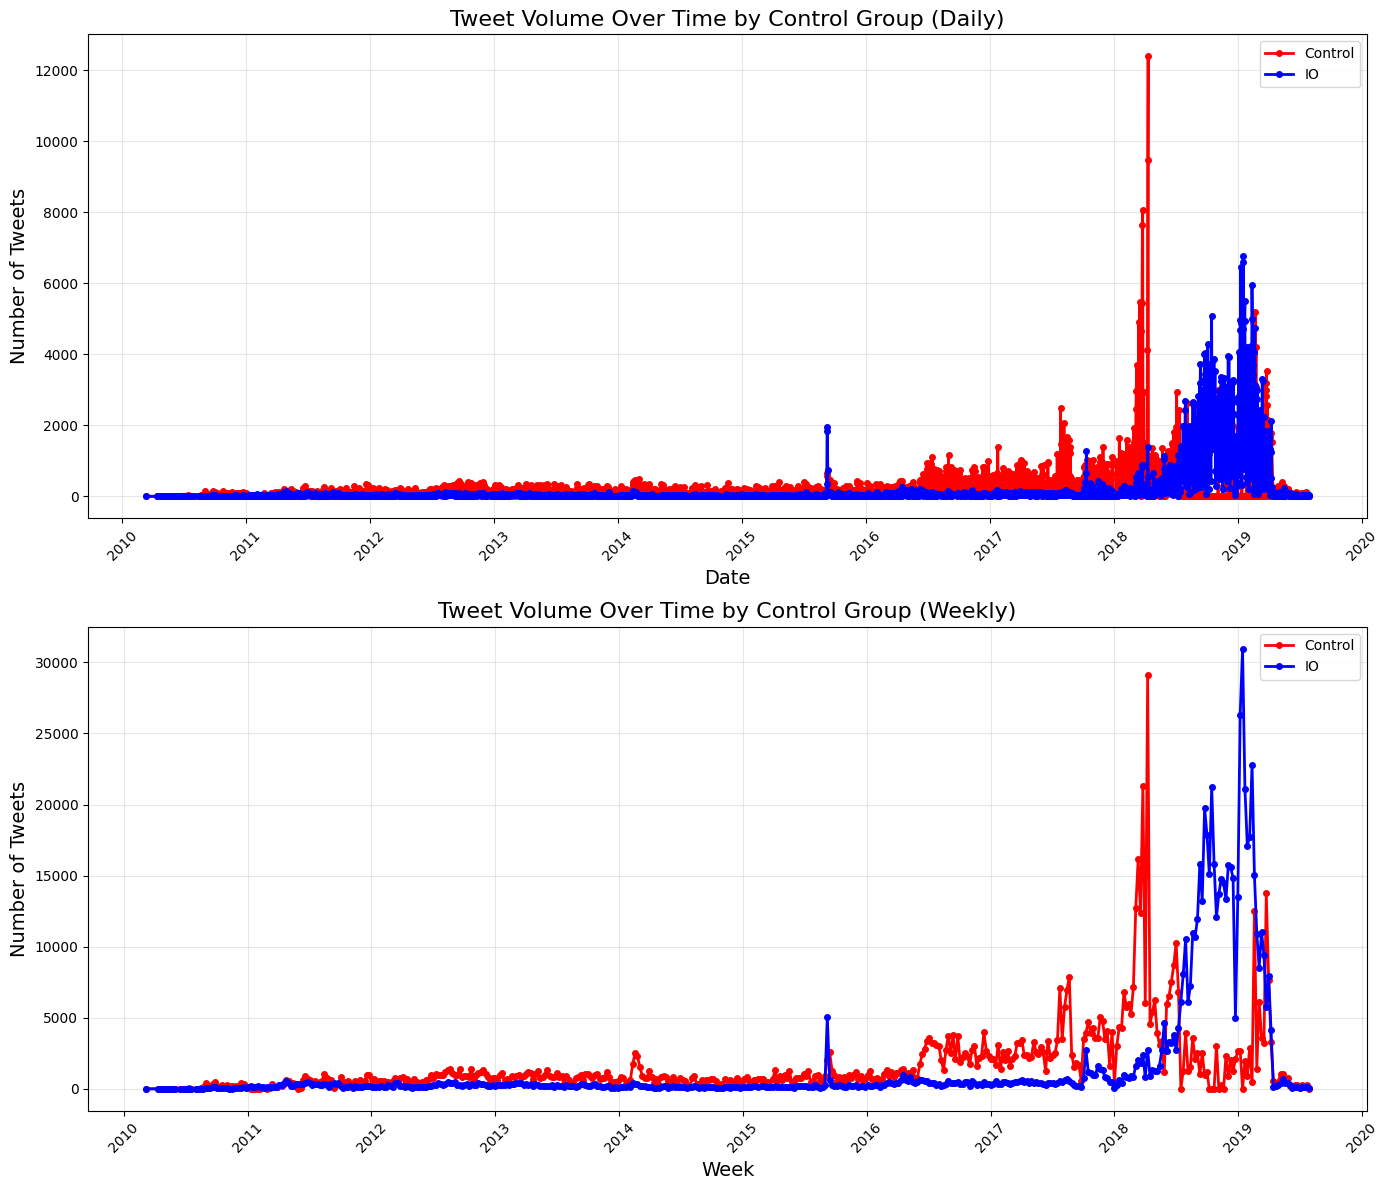

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure post_time is datetime and drop NaNs
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# --- Daily ---
tweets_per_day_control = df.groupby([df["post_time"].dt.date, "is_control"]).size().unstack(fill_value=0)

# --- Weekly ---
df['week'] = df['post_time'].dt.to_period('W')
tweets_per_week_control = df.groupby(['week', 'is_control']).size().unstack(fill_value=0)
weeks_as_dates = tweets_per_week_control.index.to_timestamp()

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for ax, x, data, title, xlabel in [
    (axes[0], tweets_per_day_control.index, tweets_per_day_control, "Tweet Volume Over Time by Control Group (Daily)", "Date"),
    (axes[1], weeks_as_dates, tweets_per_week_control, "Tweet Volume Over Time by Control Group (Weekly)", "Week"),
]:
    ax.plot(x, data[True], label='Control', color='red', marker='o', markersize=4, linewidth=2)
    ax.plot(x, data[False], label='IO', color='blue', marker='o', markersize=4, linewidth=2)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("Number of Tweets", fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

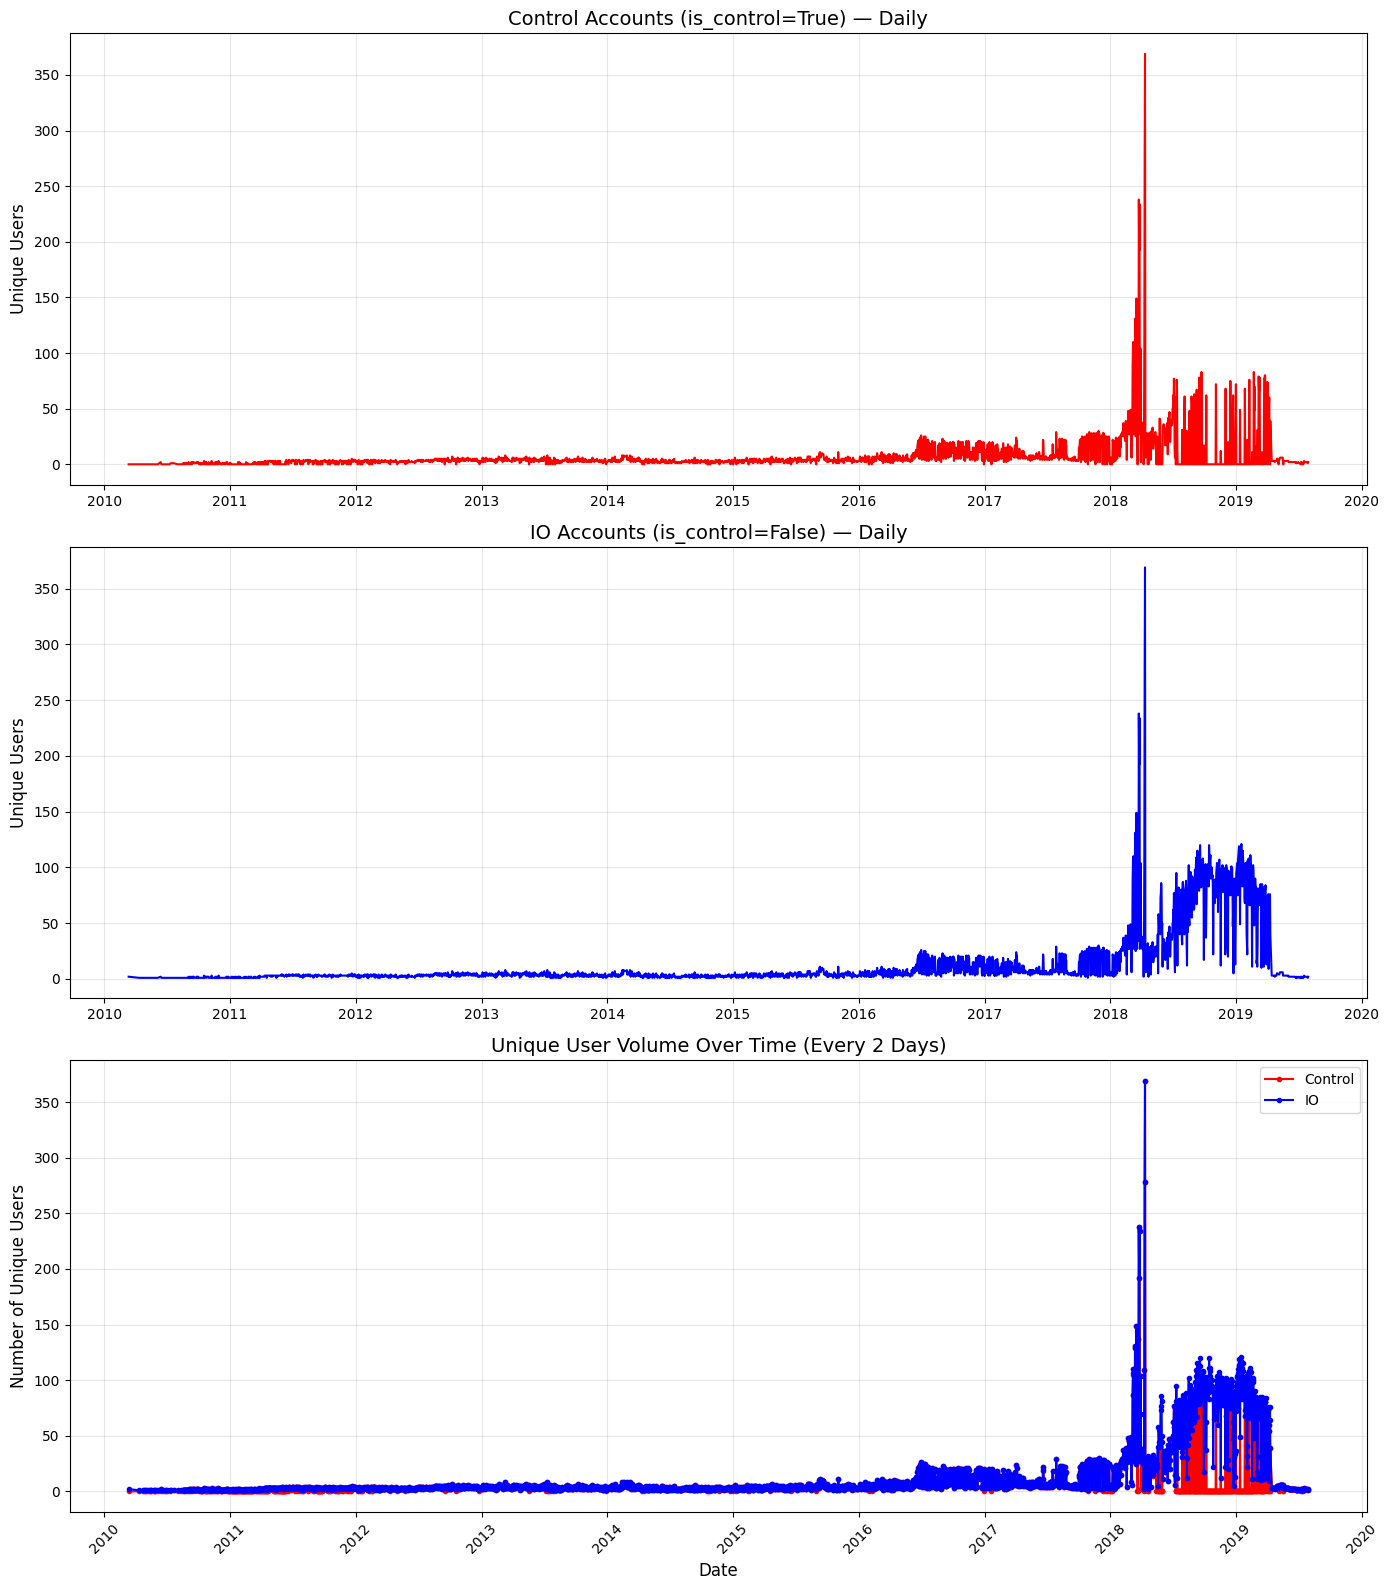

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure post_time is datetime and drop NaNs
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# --- Daily ---
unique_users_per_day = (
    df.groupby([df["post_time"].dt.date, "is_control"])["accountid"]
      .nunique()
      .unstack(fill_value=0)
)

# --- Every 2 Days ---
df['period'] = df['post_time'].dt.to_period('2D')
unique_users_per_period = (
    df.groupby(['period', 'is_control'])['accountid']
      .nunique()
      .unstack(fill_value=0)
)

# --- Plot: 3 subplots ---
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Daily - Control
axes[0].plot(unique_users_per_day.index, unique_users_per_day[True], color='red')
axes[0].set_title("Control Accounts (is_control=True) — Daily", fontsize=14)
axes[0].set_ylabel("Unique Users", fontsize=12)
axes[0].grid(alpha=0.3)

# Daily - IO
axes[1].plot(unique_users_per_day.index, unique_users_per_day[False], color='blue')
axes[1].set_title("IO Accounts (is_control=False) — Daily", fontsize=14)
axes[1].set_ylabel("Unique Users", fontsize=12)
axes[1].grid(alpha=0.3)

# Every 2 Days - Both
axes[2].plot(unique_users_per_period.index.to_timestamp(), unique_users_per_period[True],
             label='Control', color='red', marker='o', markersize=3)
axes[2].plot(unique_users_per_period.index.to_timestamp(), unique_users_per_period[False],
             label='IO', color='blue', marker='o', markersize=3)
axes[2].set_title("Unique User Volume Over Time (Every 2 Days)", fontsize=14)
axes[2].set_xlabel("Date", fontsize=12)
axes[2].set_ylabel("Number of Unique Users", fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create pipeline Initial boost

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# ===============================
# PARAMETERS
# ===============================

FREQ        = "5min"
Z_THRESHOLD = 3
WINDOW      = pd.Timedelta(minutes=5)

# ===============================
# 1. PREPARE DATA
# ===============================

df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# ===============================
# 2. BUILD TIME SERIES
# ===============================

volume_g = (
    df.groupby(pd.Grouper(key="post_time", freq=FREQ))
      .size()
      .to_frame(name="volume")
)

# ===============================
# 3. COMPUTE DELTA & Z-SCORE
# ===============================

volume_g["delta"] = volume_g["volume"].diff()

volume_g["z_score"] = (
    (volume_g["delta"] - volume_g["delta"].mean())
    / volume_g["delta"].std()
)

volume_g = volume_g.dropna()

# ===============================
# 4. IDENTIFY BURSTS
# ===============================

bursts_g = volume_g[volume_g["z_score"] > Z_THRESHOLD]

print(f"Detected {len(bursts_g)} burst windows")

# ===============================
# 5. COMPUTE BOOST AUTHORS
# ===============================

boost_records_g = []

for burst_time, row in tqdm(
    bursts_g.iterrows(),
    total=len(bursts_g),
    desc="Processing bursts"
):

    prior_posts = df[
        (df["post_time"] >= burst_time - WINDOW) &
        (df["post_time"] <  burst_time)
    ]

    unique_users = prior_posts["accountid"].unique()

    if len(unique_users) == 0:
        continue

    burst_weight = row["delta"] / len(unique_users)

    for user in unique_users:
        boost_records_g.append(
            (user, burst_weight, burst_time)
        )

# ===============================
# 6. FINAL BOOST SCORE
# ===============================

boost_df_g = pd.DataFrame(
    boost_records_g,
    columns=["accountid", "burst_weight", "burst_time"]
)

boost_df_g["burst_time"] = pd.to_datetime(boost_df_g["burst_time"])

boost_scores_g = (
    boost_df_g
    .groupby("accountid")["burst_weight"]
    .sum()
    .sort_values(ascending=False)
)

boost_df_final_g = boost_scores_g.reset_index()
boost_df_final_g.columns = ["accountid", "boost_score"]

boost_merged_g = boost_df_final_g.merge(
    df[["accountid", "is_control"]].drop_duplicates(),
    on="accountid",
    how="left"
)

print("\nTop Boost Authors:")
print(boost_merged_g.head(20))




Detected 5940 burst windows


Processing bursts: 100%|██████████| 5940/5940 [00:52<00:00, 112.08it/s]



Top Boost Authors:
                                     accountid   boost_score  is_control
0   9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115  10325.216940       False
1   70977662b5d96b2cf7604f9de940a581576abcd991   4050.939597       False
2   71b45b9cfbe033acf94c15763207cc9f35746ad22a   3853.124571       False
3   cea0b6abc111f3ee47a98af23b1a594373469df377   2659.149089       False
4   142f97ce405a79eb952d0f2104b784a0488fc08e2a   2514.453525       False
5   0d3b88567bf65211bb328ab87185c347edd4f29f9a   2073.440275       False
6   cd0b8e047f5b20eed79cf903fd915afdf4458bc3b4   2069.751054       False
7   4356e554e26d3b89f45ecfdee41cc2bd57a86bf2bb   1967.342615       False
8   fa300e59c6f5cb1d7893b6a96cf9770fc8ea185342   1953.313342       False
9   6d5c983bd23cf9fcc259f8da6e7500ad270f06e0ca   1860.241637       False
10  b2ee4f11ad64bd65b56ef6ea0a24e929c57ed51ef1   1740.010329       False
11  ab27c1a26d0d24fdea455ac9d7272fb92cccc1c46f   1688.386192       False
12  096ca573d172abad763b2a566e6

In [ ]:
# ===============================
# 7. SAVE
# ===============================

boost_df_g.to_csv("/content/drive/Shareddrives/KeyBoostAuthor/old/Boost/data/boost_df_raw_global.csv", index=False)
boost_merged_g.to_csv("/content/drive/Shareddrives/KeyBoostAuthor/old/Boost/data/boost_merged_global.csv", index=False)

print("\nSaved:")
print(f"  boost_df_raw_global.csv  — {len(boost_df_g):,} rows")
print(f"  boost_merged_global.csv  — {len(boost_merged_g):,} rows")

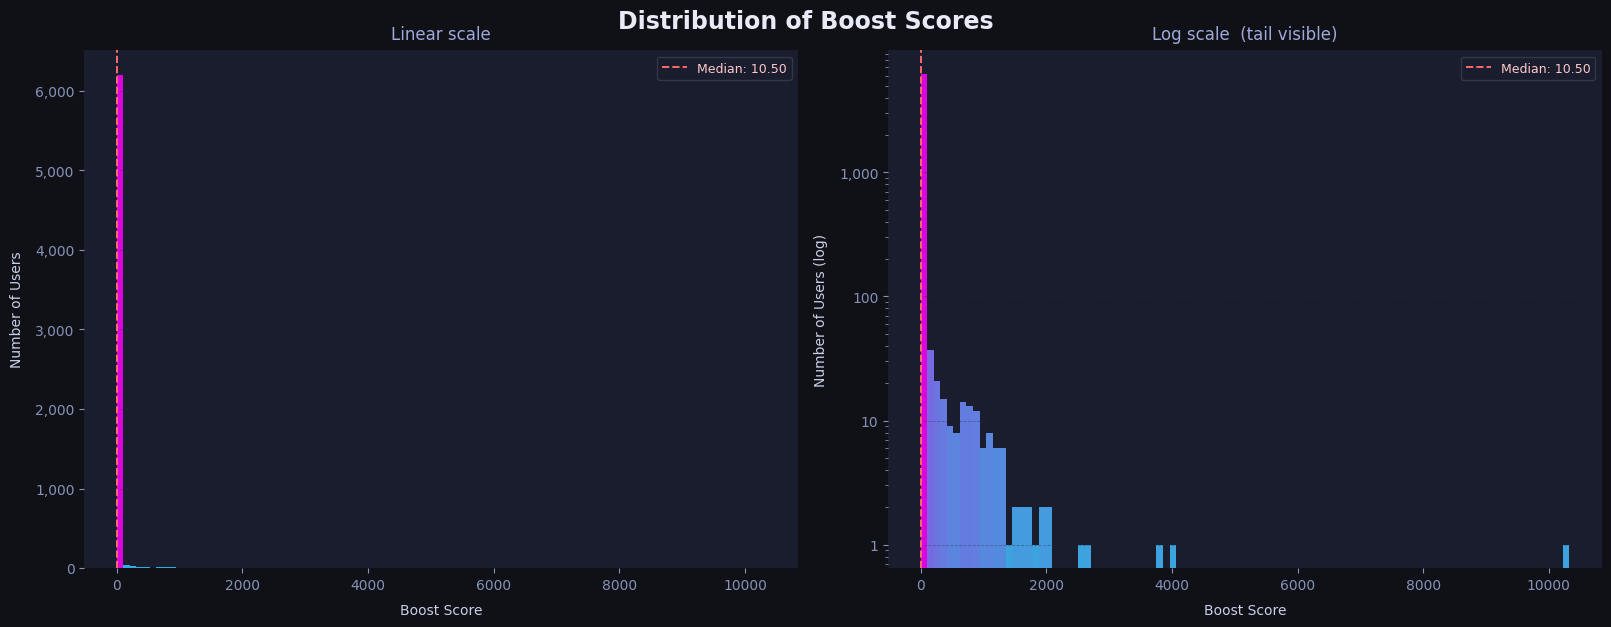

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ----------------------------------------------------- #
# Style setup
# ----------------------------------------------------- #

def plot_boost_distribution(data, title="Distribution of Boost Scores",
                             bins=100, save_path="boost_score_distribution.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    data   = data.dropna()
    bins   = np.linspace(data.min(), data.max(), bins)
    cmap   = plt.cm.cool
    ACCENT = "#5c7cfa"

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)

    # ── Panel 1 : Linear ─────────────────────────────────────────────────────────
    ax1 = axes[0]
    n, _, patches = ax1.hist(data, bins=bins, color=ACCENT, edgecolor="none", alpha=0.85)
    for count, patch in zip(n, patches):
        patch.set_facecolor(cmap(count / n.max() * 0.8 + 0.2))

    ax1.set_title("Linear scale", fontsize=12, color="#9fa8da", pad=8)
    ax1.set_xlabel("Boost Score", labelpad=8)
    ax1.set_ylabel("Number of Users", labelpad=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax1.grid(axis="y", alpha=0.4)
    ax1.spines[:].set_visible(False)

    # ── Panel 2 : Log Y ───────────────────────────────────────────────────────
    ax2 = axes[1]
    n2, _, patches2 = ax2.hist(data, bins=bins, color=ACCENT, edgecolor="none", alpha=0.85, log=True)
    max_n2 = n2[n2 > 0].max()
    for count, patch in zip(n2, patches2):
        if count > 0:
            patch.set_facecolor(cmap(np.log1p(count) / np.log1p(max_n2) * 0.8 + 0.2))

    ax2.set_title("Log scale  (tail visible)", fontsize=12, color="#9fa8da", pad=8)
    ax2.set_xlabel("Boost Score", labelpad=8)
    ax2.set_ylabel("Number of Users (log)", labelpad=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax2.grid(axis="y", alpha=0.4)
    ax2.spines[:].set_visible(False)

    # ── Median line ───────────────────────────────────────────────────────────
    median_val = data.median()
    for ax in axes:
        ax.axvline(median_val, color="#ff6b6b", linewidth=1.4,
                   linestyle="--", label=f"Median: {median_val:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_distribution(boost_merged_g["boost_score"])

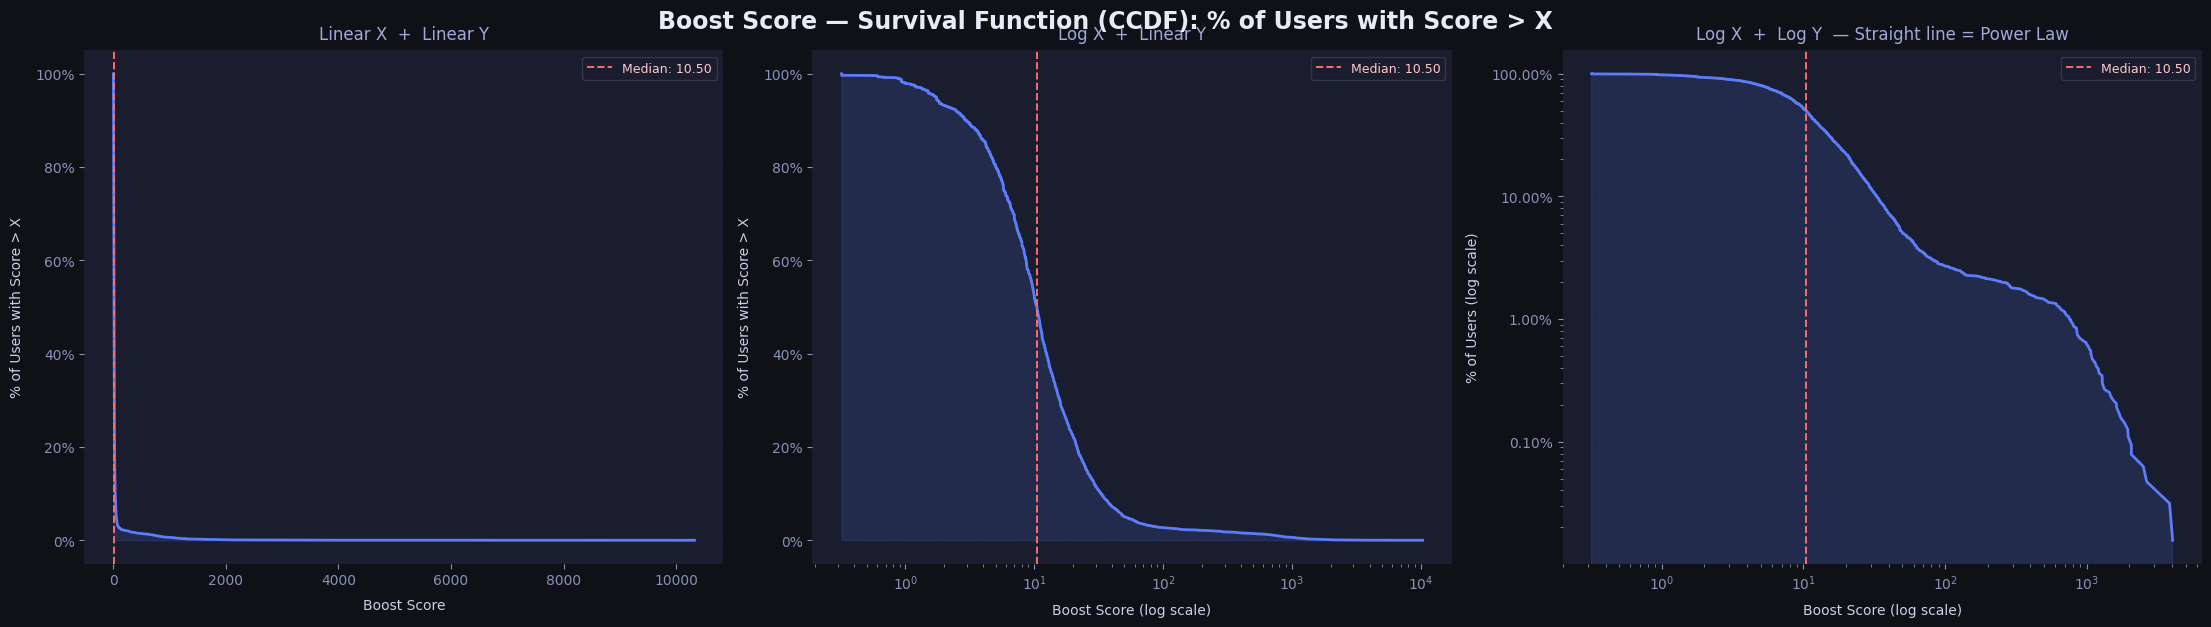

In [ ]:
def plot_boost_ccdf(data, title="Boost Score — Survival Function (CCDF): % of Users with Score > X",
                    save_path="boost_score_ccdf.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    # ── Data preparation ──────────────────────────────────────────────────────
    data       = data.dropna()
    data_pos   = np.sort(data[data > 0])
    ccdf       = 1 - np.arange(1, len(data_pos) + 1) / len(data_pos)
    median_val = data.median()
    ACCENT     = "#5c7cfa"

    fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
    fig.suptitle(title, fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)

    # ── Panel configs ─────────────────────────────────────────────────────────
    panels = [
        dict(ax=axes[0], xscale="linear", yscale="linear",
             title="Linear X  +  Linear Y",     xlabel="Boost Score"),
        dict(ax=axes[1], xscale="log",    yscale="linear",
             title="Log X  +  Linear Y",         xlabel="Boost Score (log scale)"),
        dict(ax=axes[2], xscale="log",    yscale="log",
             title="Log X  +  Log Y  — Straight line = Power Law",
             xlabel="Boost Score (log scale)"),
    ]

    for p in panels:
        ax   = p["ax"]
        mask = ccdf > 0 if p["yscale"] == "log" else slice(None)
        x, y = data_pos[mask], ccdf[mask]

        ax.plot(x, y, color=ACCENT, linewidth=2)
        ax.fill_between(x, y, alpha=0.15, color=ACCENT)
        ax.set_xscale(p["xscale"])
        ax.set_yscale(p["yscale"])
        ax.set_title(p["title"], fontsize=12, color="#9fa8da", pad=8)
        ax.set_xlabel(p["xlabel"], labelpad=8)
        ax.set_ylabel("% of Users with Score > X" if p["yscale"] == "linear"
                      else "% of Users (log scale)", labelpad=8)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(
            xmax=1, decimals=0 if p["yscale"] == "linear" else 2))
        if p["xscale"] == "log":
            ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
        ax.grid(alpha=0.4)
        ax.spines[:].set_visible(False)

    # ── Median line ───────────────────────────────────────────────────────────
    for ax in axes:
        ax.axvline(median_val, color="#ff6b6b", linewidth=1.4,
                   linestyle="--", label=f"Median: {median_val:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_ccdf(boost_merged_g["boost_score"])

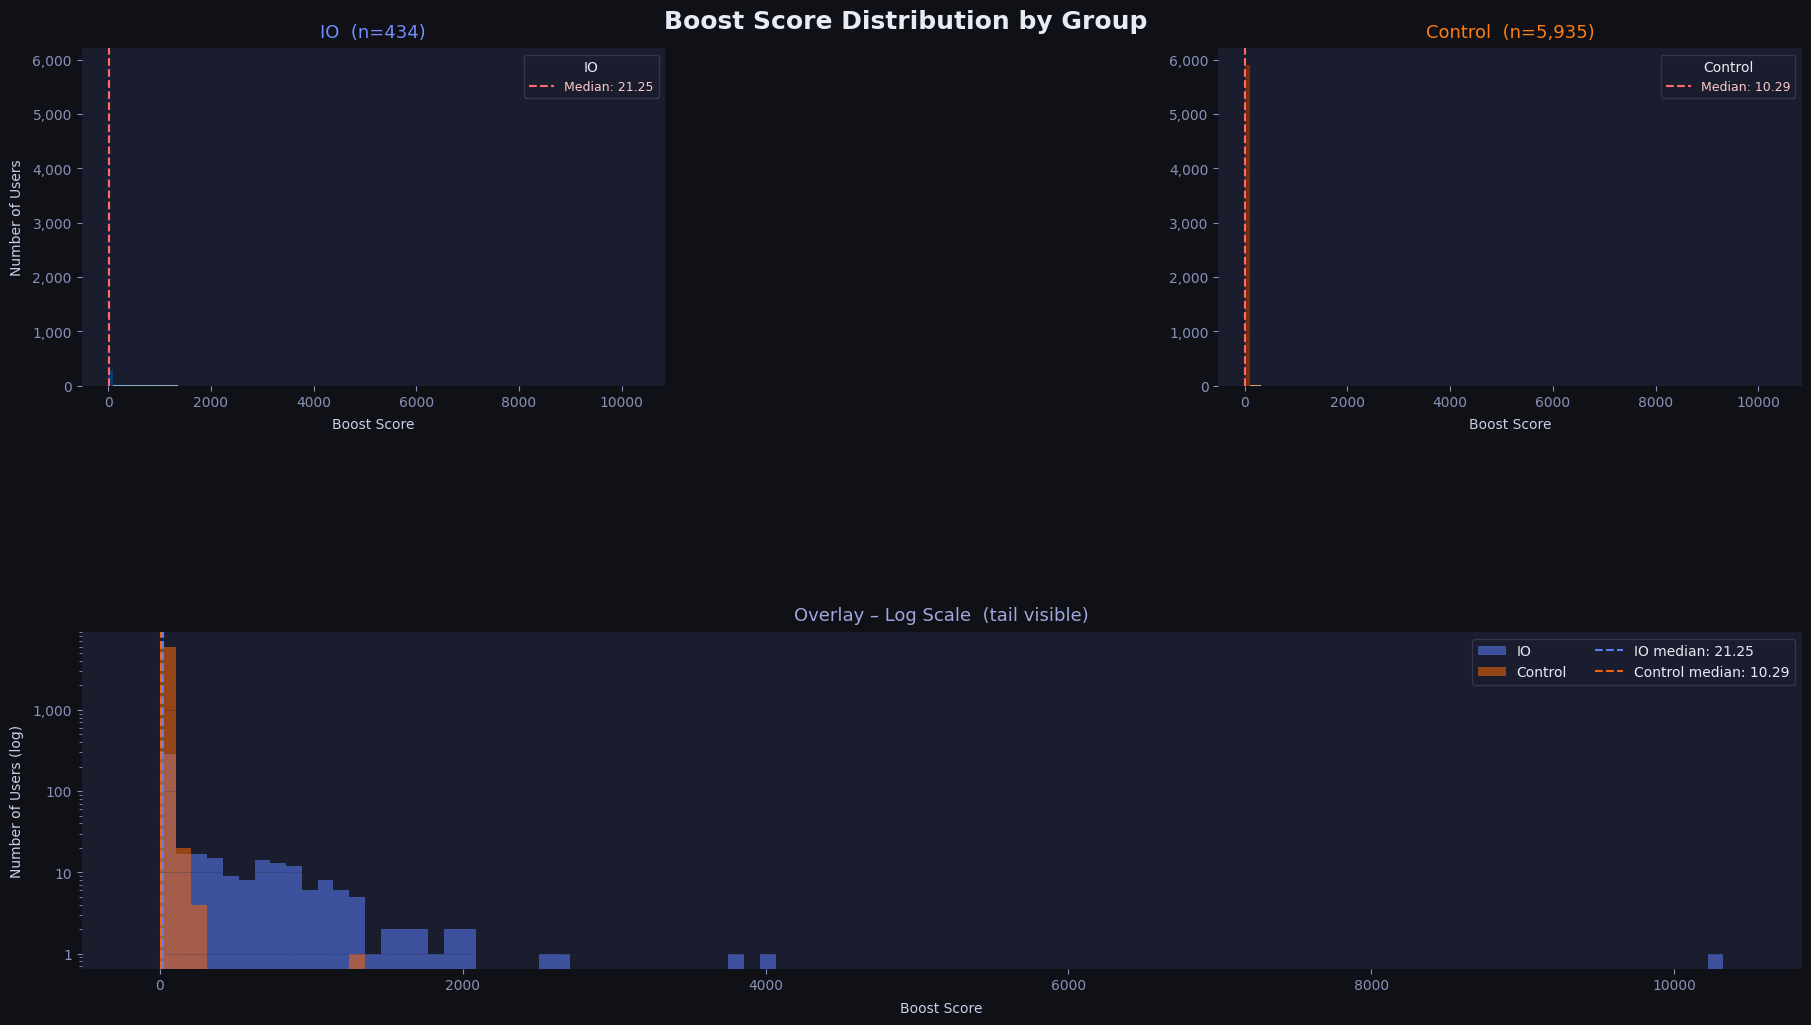

In [ ]:
def plot_boost_by_group(df, score_col="boost_score", group_col="is_control",
                        title="Boost Score Distribution by Group",
                        save_path="boost_score_by_group.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    COLOR_IO      = "#5c7cfa"
    COLOR_CONTROL = "#f76707"

    io_data      = df[df[group_col] == False][score_col].dropna()
    control_data = df[df[group_col] == True][score_col].dropna()

    all_data = np.concatenate([io_data, control_data])
    bins     = np.linspace(all_data.min(), all_data.max(), 100)

    def styled_hist(ax, data, color, label, log=False):
        n, _, patches = ax.hist(data, bins=bins, color=color,
                                edgecolor="none", alpha=0.85, log=log)
        cmap  = plt.cm.Blues if color == COLOR_IO else plt.cm.Oranges
        max_n = n[n > 0].max() if log else n.max()
        norm  = np.log1p if log else lambda x: x
        for cnt, patch in zip(n, patches):
            if cnt > 0:
                patch.set_facecolor(cmap(norm(cnt) / norm(max_n) * 0.6 + 0.35))
        med = data.median()
        ax.axvline(med, color="#ff6b6b", linewidth=1.5, linestyle="--",
                   label=f"Median: {med:.2f}")
        ax.legend(framealpha=0.15, labelcolor="#ffc9c9", fontsize=9,
                  title=label, title_fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.grid(axis="y", alpha=0.4)
        ax.spines[:].set_visible(False)

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    fig.suptitle(title, fontsize=18, fontweight="bold", color="#e8eaf6", y=1.01)

    gs     = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28)
    ax_io  = fig.add_subplot(gs[0, 0])
    ax_ctl = fig.add_subplot(gs[0, 1], sharey=ax_io, sharex=ax_io)
    ax_ovr = fig.add_subplot(gs[1, :], sharex=ax_io)

    # ── Top-left: IO ──────────────────────────────────────────────────────────
    styled_hist(ax_io, io_data, COLOR_IO, "IO")
    ax_io.set_title(f"IO  (n={len(io_data):,})", fontsize=13, color="#748ffc", pad=8)
    ax_io.set_xlabel("Boost Score", labelpad=6)
    ax_io.set_ylabel("Number of Users", labelpad=6)

    # ── Top-right: Control ────────────────────────────────────────────────────
    styled_hist(ax_ctl, control_data, COLOR_CONTROL, "Control")
    ax_ctl.set_title(f"Control  (n={len(control_data):,})", fontsize=13,
                     color="#fd7e14", pad=8)
    ax_ctl.set_xlabel("Boost Score", labelpad=6)
    ax_ctl.tick_params(labelleft=True)

    # ── Bottom: Overlay ───────────────────────────────────────────────────────
    ax_ovr.hist(io_data,      bins=bins, alpha=0.55, color=COLOR_IO,
                edgecolor="none", log=True, label="IO")
    ax_ovr.hist(control_data, bins=bins, alpha=0.55, color=COLOR_CONTROL,
                edgecolor="none", log=True, label="Control")

    for val, col, lbl in [
        (io_data.median(),      COLOR_IO,      f"IO median: {io_data.median():.2f}"),
        (control_data.median(), COLOR_CONTROL, f"Control median: {control_data.median():.2f}"),
    ]:
        ax_ovr.axvline(val, color=col, linewidth=1.5, linestyle="--", label=lbl)

    ax_ovr.set_title("Overlay – Log Scale  (tail visible)", fontsize=13,
                     color="#9fa8da", pad=8)
    ax_ovr.set_xlabel("Boost Score", labelpad=6)
    ax_ovr.set_ylabel("Number of Users (log)", labelpad=6)
    ax_ovr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_ovr.legend(framealpha=0.15, fontsize=10, ncol=2)
    ax_ovr.grid(axis="y", alpha=0.4)
    ax_ovr.spines[:].set_visible(False)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Usage:
plot_boost_by_group(boost_merged_g)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_boost_boxplot(df, score_col="boost_score", group_col="is_control",
                       title="Boost Score Distribution by Group",
                       save_path="boost_boxplot.png"):

    plt.rcParams.update({
        "figure.facecolor": "#0f1117",
        "axes.facecolor":   "#1a1d2e",
        "axes.edgecolor":   "#2e3250",
        "axes.labelcolor":  "#c9cfe8",
        "xtick.color":      "#8891b8",
        "ytick.color":      "#8891b8",
        "text.color":       "#e8eaf6",
        "grid.color":       "#252840",
        "grid.linestyle":   "--",
        "grid.linewidth":   0.6,
        "font.family":      "DejaVu Sans",
    })

    COLOR_IO      = "#5c7cfa"
    COLOR_CONTROL = "#f76707"

    io_data      = df[df[group_col] == False][score_col].dropna()
    control_data = df[df[group_col] == True ][score_col].dropna()

    fig, ax = plt.subplots(figsize=(10, 7))

    for data, pos, color, label in zip(
        [io_data,  control_data],
        [1,        2],
        [COLOR_IO, COLOR_CONTROL],
        ["IO",     "Control"],
    ):
        ax.boxplot(
            data, positions=[pos], widths=0.45,
            patch_artist=True, notch=True, showfliers=False,
            medianprops=dict(color="#ffffff", linewidth=2.5),
            boxprops=dict(facecolor=color, alpha=0.35, linewidth=0),
            whiskerprops=dict(color=color, linewidth=1.4, linestyle="--"),
            capprops=dict(color=color, linewidth=2),
        )

        # ── jittered outliers (above 95th pct) ───────────────────────────
        outliers = data[data > np.percentile(data, 95)]
        jitter   = np.random.uniform(-0.12, 0.12, size=len(outliers))
        ax.scatter(pos + jitter, outliers, color=color, alpha=0.25,
                   s=12, linewidths=0, zorder=3)

        # ── annotate median & IQR ─────────────────────────────────────────
        med, q1, q3 = data.median(), data.quantile(0.25), data.quantile(0.75)
        y0 = ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1
        ax.text(pos, y0,
                f"Median: {med:,.1f}\nIQR: {q1:,.0f}–{q3:,.0f}",
                ha="center", va="bottom", fontsize=8.5, color=color,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1d2e",
                          edgecolor=color, alpha=0.7))

    # ── axes ──────────────────────────────────────────────────────────────────
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.4)
    ax.grid(axis="x", visible=False)
    ax.spines[:].set_visible(False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["IO", "Control"], fontsize=13)
    ax.set_xlabel("Group", labelpad=10, fontsize=12)
    ax.set_ylabel("Boost Score  (log scale)", labelpad=10, fontsize=12)
    ax.set_title(title, fontsize=16, fontweight="bold", color="#e8eaf6", pad=16)

    ax.legend(handles=[
        mpatches.Patch(facecolor=COLOR_IO,      alpha=0.7, label=f"IO  (n={len(io_data):,})"),
        mpatches.Patch(facecolor=COLOR_CONTROL, alpha=0.7, label=f"Control  (n={len(control_data):,})"),
    ], framealpha=0.15, fontsize=10, loc="upper right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()





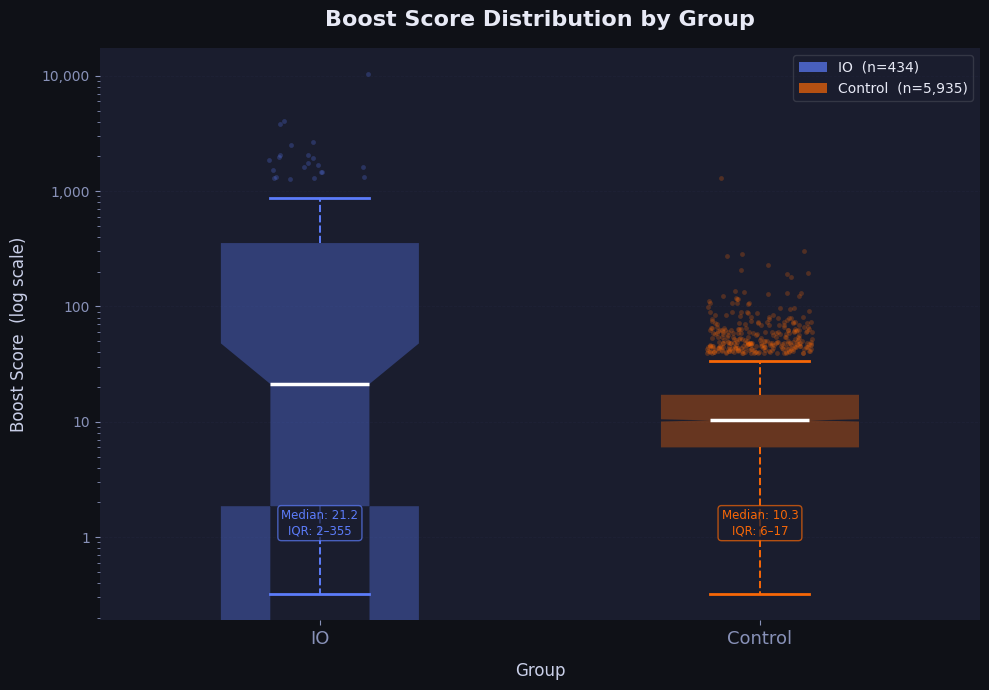

In [ ]:
plot_boost_boxplot(boost_merged_g)

In [ ]:
import pandas as pd

boost_merged_g = pd.read_csv("/content/drive/Shareddrives/KeyBoostAuthor/old/Boost/boost_scores_boost_merged_global.csv")
boost_df_g = pd.read_csv("/content/drive/Shareddrives/KeyBoostAuthor/old/Boost/boost_scores_boost_df_raw_global.csv")

# Convert 'burst_time' to datetime after loading from CSV
boost_df_g['burst_time'] = pd.to_datetime(boost_df_g['burst_time'])


consistency_global.csv — 6,369 rows


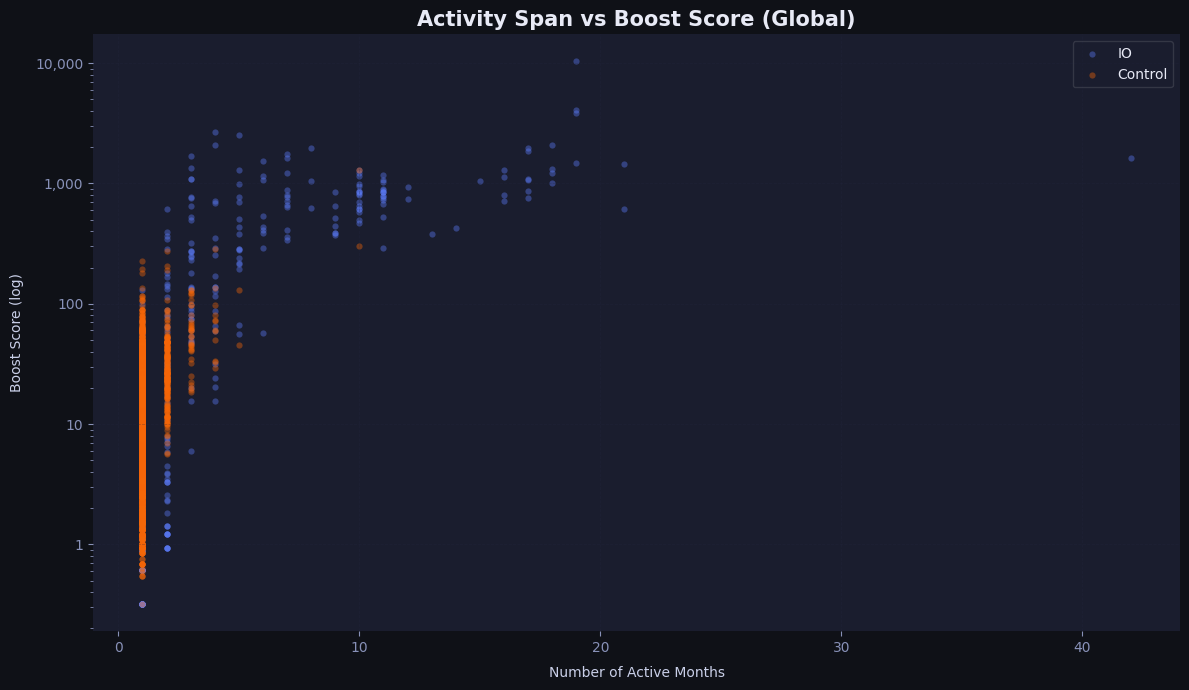

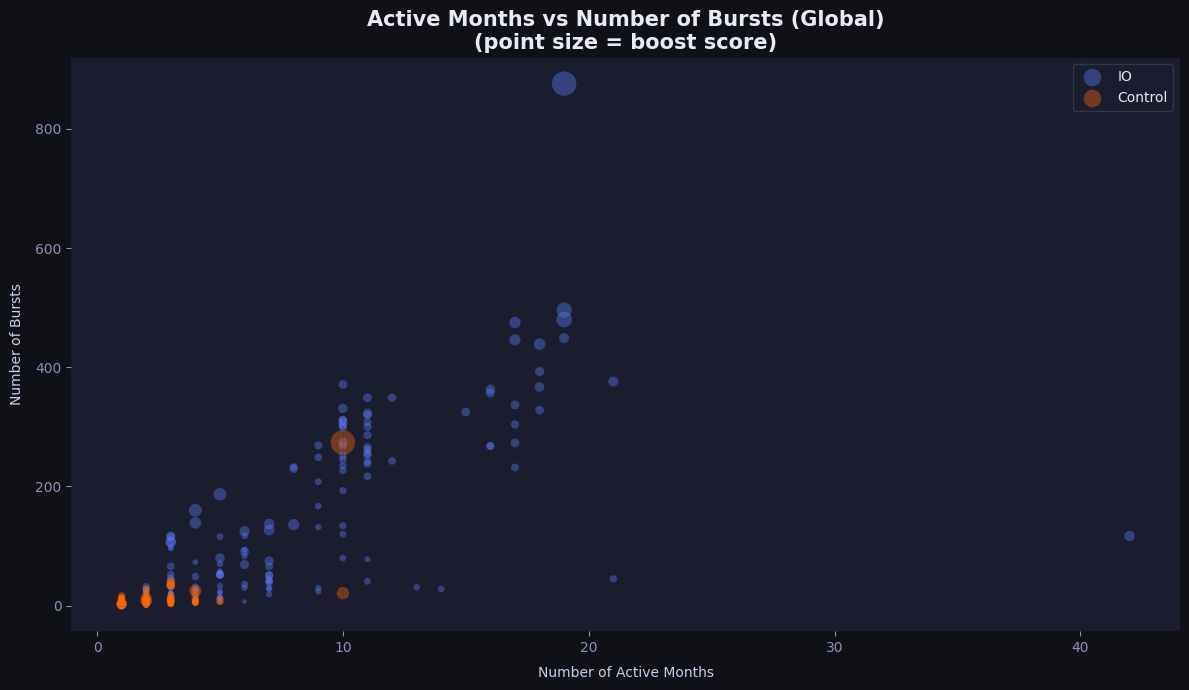

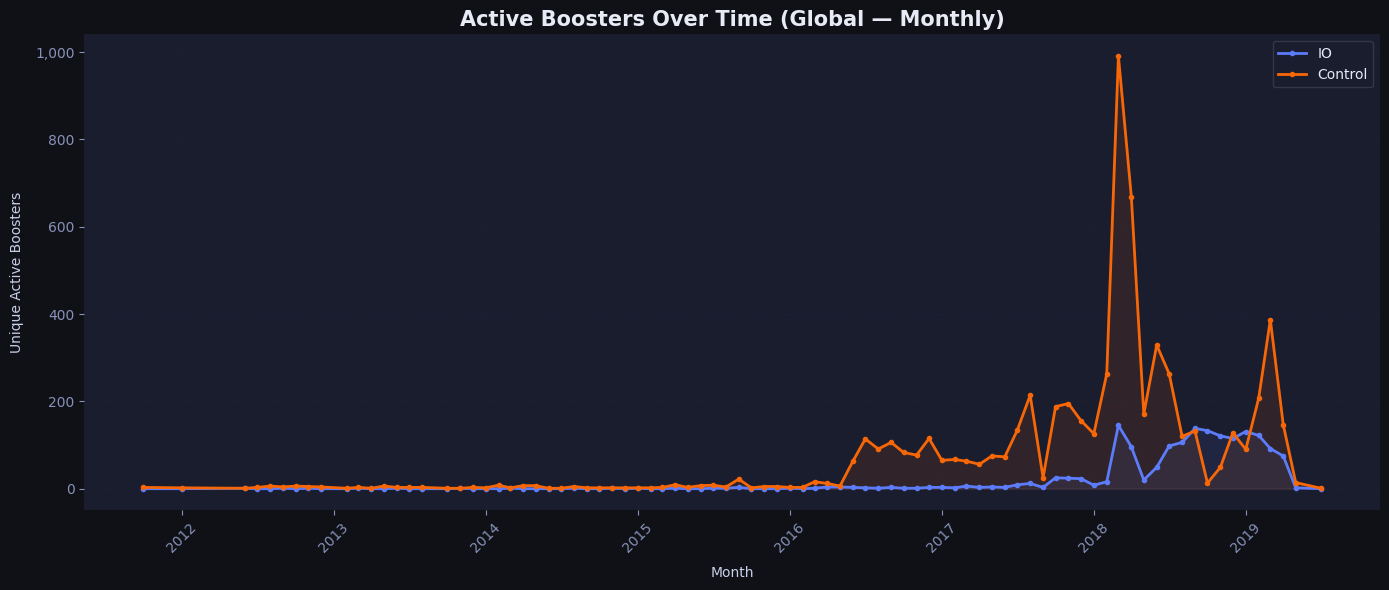

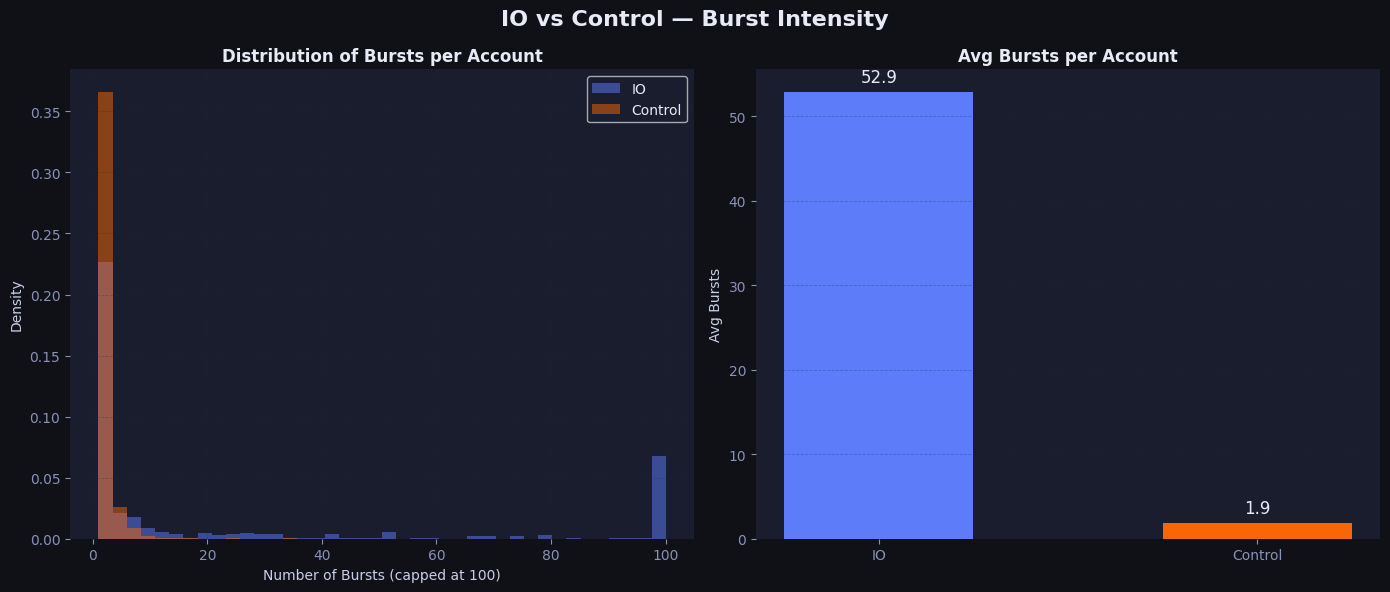

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d2e",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c9cfe8",
    "xtick.color":      "#8891b8",
    "ytick.color":      "#8891b8",
    "text.color":       "#e8eaf6",
    "grid.color":       "#252840",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
})

COLOR_IO      = "#5c7cfa"
COLOR_CONTROL = "#f76707"



consistency_g = (
    boost_df_g.groupby("accountid")
    .agg(
        total_score = ("burst_weight", "sum"),
        n_bursts    = ("burst_time",   "count"),
        n_months    = ("burst_time",   lambda x: x.dt.to_period("M").nunique()),
        first_burst = ("burst_time",   "min"),
        last_burst  = ("burst_time",   "max"),
    )
    .reset_index()
)

consistency_g["active_months_span"] = (
    (consistency_g["last_burst"] - consistency_g["first_burst"])
    / pd.Timedelta(days=30)
).round(1)

consistency_g = consistency_g.merge(
    df[["accountid", "is_control"]].drop_duplicates(),
    on="accountid", how="left"
)

consistency_g.to_csv("consistency_global.csv", index=False)
print(f"consistency_global.csv — {len(consistency_g):,} rows")

# =====================================================
# PLOTS
# =====================================================

io_g  = consistency_g[consistency_g["is_control"] == False]
ctl_g = consistency_g[consistency_g["is_control"] == True]

# ── 1. Scatter: n_months vs boost_score ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))
for data, color, label in [(io_g, COLOR_IO, "IO"), (ctl_g, COLOR_CONTROL, "Control")]:
    ax.scatter(data["n_months"], data["total_score"],
               color=color, alpha=0.4, s=20, label=label, linewidths=0)

ax.set_yscale("log")
ax.set_title("Activity Span vs Boost Score (Global)", fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Number of Active Months", labelpad=8)
ax.set_ylabel("Boost Score (log)", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig("g_scatter_months_vs_score.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── 2. Scatter: n_months vs n_bursts (במקום n_entities שאין בשיטה זו) ────────

fig, ax = plt.subplots(figsize=(12, 7))
for data, color, label in [(io_g, COLOR_IO, "IO"), (ctl_g, COLOR_CONTROL, "Control")]:
    ax.scatter(data["n_months"], data["n_bursts"],
               s=data["total_score"] / data["total_score"].max() * 300 + 10,
               color=color, alpha=0.4, label=label, linewidths=0)

ax.set_title("Active Months vs Number of Bursts (Global)\n(point size = boost score)",
             fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Number of Active Months", labelpad=8)
ax.set_ylabel("Number of Bursts", labelpad=8)
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig("g_scatter_bursts_vs_months.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ── 3. Timeline: active boosters over time ────────────────────────────────────

boost_df_g["month"] = boost_df_g["burst_time"].dt.to_period("M")

timeline_g = (
    boost_df_g.merge(consistency_g[["accountid", "is_control"]], on="accountid", how="left")
    .groupby(["month", "is_control"])["accountid"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = timeline_g.index.to_timestamp()

for col, color, label in [(False, COLOR_IO, "IO"), (True, COLOR_CONTROL, "Control")]:
    if col in timeline_g.columns:
        ax.plot(x, timeline_g[col], color=color, linewidth=2, label=label, marker="o", markersize=3)
        ax.fill_between(x, timeline_g[col], alpha=0.1, color=color)

ax.set_title("Active Boosters Over Time (Global — Monthly)", fontsize=15, fontweight="bold", color="#e8eaf6")
ax.set_xlabel("Month", labelpad=8)
ax.set_ylabel("Unique Active Boosters", labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(framealpha=0.15, fontsize=10)
ax.grid(alpha=0.3)
ax.spines[:].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("g_timeline_boosters.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()





fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, color, label in [
    (axes[0], io_g,  COLOR_IO,      "IO"),
    (axes[0], ctl_g, COLOR_CONTROL, "Control")
]:
    ax.hist(data["n_bursts"].clip(upper=100), bins=40,
            color=color, alpha=0.5, label=label, density=True)

axes[0].set_title("Distribution of Bursts per Account", fontweight="bold")
axes[0].set_xlabel("Number of Bursts (capped at 100)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines[:].set_visible(False)

ax2 = axes[1]
bars = ax2.bar(["IO", "Control"],
               [io_g["n_bursts"].mean(), ctl_g["n_bursts"].mean()],
               color=[COLOR_IO, COLOR_CONTROL], width=0.5)
ax2.bar_label(bars, fmt="%.1f", padding=4, color="#e8eaf6", fontsize=12)
ax2.set_title("Avg Bursts per Account", fontweight="bold")
ax2.set_ylabel("Avg Bursts")
ax2.grid(alpha=0.3, axis="y")
ax2.spines[:].set_visible(False)

plt.suptitle("IO vs Control — Burst Intensity", fontsize=16, fontweight="bold", color="#e8eaf6")
plt.tight_layout()
plt.savefig("burst_intensity.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()